In [1]:
!pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.1 MB/s eta 0:00:00



Running Solid (10 K)...
  T=10K: equilibrating...


/usr/local/lib/python3.12/dist-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


  T=10K: collecting...

Running Liquid (85 K)...
  T=85K: equilibrating...
  T=85K: collecting...

Running Gas (200 K)...
  T=200K: equilibrating...
  T=200K: collecting...


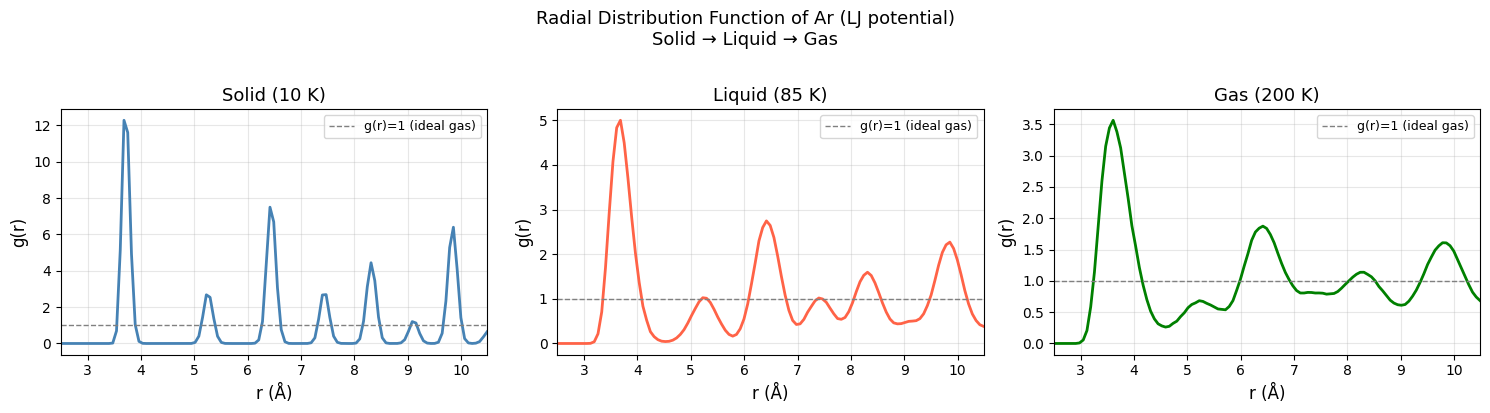

Done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ase import units, Atoms
from ase.lattice.cubic import FaceCenteredCubic
from ase.calculators.lj import LennardJones
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.langevin import Langevin

# ── Ar 的 LJ 參數（文獻值）──────────────────────
# ε = 0.0104 eV, σ = 3.40 Å
# 固態/液態/氣態轉變溫度：84K / 87K / 150K+
eps_ar = 0.0104   # eV
sig_ar = 3.40     # Å

def run_md_and_rdf(T_K, n_equil=300, n_collect=200, label=''):
    """給定溫度 T_K，跑 Langevin NVT，收集 RDF"""

    # 建立 FCC Ar 晶體，4x4x4 超晶胞
    atoms = FaceCenteredCubic('Ar', size=(4,4,4), latticeconstant=5.26)
    atoms.calc = LennardJones(epsilon=eps_ar, sigma=sig_ar, rc=10.0)

    MaxwellBoltzmannDistribution(atoms, temperature_K=T_K)

    # Langevin 控溫，讓系統在目標溫度平衡
    dyn = Langevin(atoms, timestep=5*units.fs,
                   temperature_K=T_K, friction=0.05/units.fs)

    # 平衡階段（不收集）
    print(f"  T={T_K}K: equilibrating...")
    dyn.run(n_equil)

    # 收集快照
    print(f"  T={T_K}K: collecting...")
    snapshots = []
    for _ in range(n_collect):
        dyn.run(5)
        snapshots.append(atoms.get_positions().copy())

    # 計算 RDF
    cell = atoms.get_cell()
    L = cell[0,0]
    N = len(atoms)
    rho = N / L**3

    r_max = L / 2
    n_bins = 150
    dr = r_max / n_bins
    r_centers = np.linspace(dr/2, r_max - dr/2, n_bins)
    rdf_sum = np.zeros(n_bins)

    for pos in snapshots:
        counts = np.zeros(n_bins)
        for i in range(N):
            diffs = pos - pos[i]
            diffs -= L * np.round(diffs / L)
            dists = np.sqrt((diffs**2).sum(axis=1))
            dists = dists[dists > 0]
            idx = (dists / dr).astype(int)
            idx = idx[idx < n_bins]
            np.add.at(counts, idx, 1)
        shell_vols = 4 * np.pi * r_centers**2 * dr
        rdf_sum += counts / (N * rho * shell_vols)

    return r_centers, rdf_sum / len(snapshots)

# ══════════════════════════════════════════════
# 跑三個溫度
# ══════════════════════════════════════════════
configs = [
    (10,  'Solid (10 K)',  'steelblue'),
    (85,  'Liquid (85 K)', 'tomato'),
    (200, 'Gas (200 K)',   'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (T, label, color) in zip(axes, configs):
    print(f"\nRunning {label}...")
    r, g = run_md_and_rdf(T, label=label)
    ax.plot(r, g, color=color, lw=2)
    ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='g(r)=1 (ideal gas)')
    ax.set_xlabel('r (Å)', fontsize=12)
    ax.set_ylabel('g(r)', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2.5, r.max())

plt.suptitle('Radial Distribution Function of Ar (LJ potential)\nSolid → Liquid → Gas',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('rdf_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")